# 05 — Actions Training Pairs

ARO's action vocabulary is the model's building blocks — get it wrong and every
generated program breaks. This notebook makes sure the model knows each action cold.

For every action in `list-of-actions.txt`, we generate multiple training pair types:

1. **Usage** — "Show me how to use `retrieve`" → the canonical example line
2. **Alias** — alternate verbs that map to the same action (only real ARO verbs)
3. **Explanation** — "What does this statement do?" → role + preposition summary
4. **Which action** — "Which action retrieves from a repository?" → name + example
5. **In context** — a minimal Application-Start that uses the action (teaches structure)
6. **LLM-generated** — fuller feature sets, validated with `aro check`

We also add a set of static **error-pattern pairs**: every common ARO mistake paired
with the correct fix. Seeing what *not* to do is surprisingly effective training signal.

**Input:**  `../../Examples/list-of-actions.txt`
            `../data/02_knowledge/knowledge.json`
**Output:** `../data/02_knowledge/knowledge_pairs.jsonl` (appended)
            `../data/04b_actions/actions_pairs.jsonl` (own copy)

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import json, re, sys, random, subprocess
from pathlib import Path

ACTIONS_FILE = ARO_ROOT / 'Examples' / 'list-of-actions.txt'
DATA_OUT     = GLOBAL_OUT_DIR / '../data/04b_actions'
DATA_OUT.mkdir(parents=True, exist_ok=True)

OWN_FILE   = DATA_OUT / 'actions_pairs.jsonl'

with open(DATA_IN / 'knowledge.json') as f:
    kb = json.load(f)

print(f'Actions file: {ACTIONS_FILE}')
print(f'Knowledge base: {len(kb["actions"])} actions')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters
Actions file: /Users/kris/Projects/ARO-App/Examples/list-of-actions.txt
Knowledge base: 60 actions


## Parse list-of-actions.txt

In [2]:
def parse_actions_file(path):
    """
    Parses list-of-actions.txt into a list of dicts:
      { verb, role, example_line, category }
    Sections are delimited by lines containing '---'.
    """
    content = Path(path).read_text()
    lines   = content.splitlines()

    actions     = []
    current_role = 'UNKNOWN'
    role_re      = re.compile(r'^(\w+) actions', re.IGNORECASE)
    # Match lines like: Extract the <id> from the <pathParameters: id>.
    stmt_re      = re.compile(r'^([A-Z][a-zA-Z]+)\s+(?:the|a|an)?\s*<')

    for line in lines:
        stripped = line.strip()
        # Section header — detect role
        role_m = role_re.match(stripped)
        if role_m:
            current_role = role_m.group(1).upper()
            continue
        # Skip separators and headers
        if not stripped or stripped.startswith('ARO Action') or set(stripped) == {'-'}:
            continue
        # Match statement lines
        stmt_m = stmt_re.match(stripped)
        if stmt_m:
            verb = stmt_m.group(1).lower()
            actions.append({
                'verb':         verb,
                'role':         current_role,
                'example_line': stripped,
            })

    return actions

raw_actions = parse_actions_file(ACTIONS_FILE)
print(f'Parsed {len(raw_actions)} action examples')
for a in raw_actions[:5]:
    print(f'  [{a["role"]:10s}] {a["verb"]:12s} → {a["example_line"][:60]}')

Parsed 58 action examples
  [REQUEST   ] extract      → Extract the <id> from the <pathParameters: id>.
  [REQUEST   ] retrieve     → Retrieve the <user> from the <user-repository> where id = <u
  [REQUEST   ] receive      → Receive the <packet> from the <socket: message>.
  [REQUEST   ] read         → Read the <content> from the <config-file>.
  [REQUEST   ] request      → Request the <response> from the <api-url>.


## Build action metadata index

Merge parsed examples with metadata from `knowledge.json` (verbs, prepositions, description).

In [3]:
# Build a lookup: primary_verb -> action metadata
action_meta = {}
for a in kb.get('actions', []):
    for v in a.get('verbs', []):
        action_meta[v.lower()] = a

# Enrich parsed actions with metadata
for a in raw_actions:
    meta = action_meta.get(a['verb'], {})
    a['all_verbs']     = meta.get('verbs', [a['verb']])
    a['prepositions']  = meta.get('prepositions', [])
    a['description']   = meta.get('description', '')
    a['action_name']   = meta.get('name', a['verb'].capitalize() + 'Action')

print(f'Enriched {len(raw_actions)} actions with metadata')
print(f'Actions with description: {sum(1 for a in raw_actions if a["description"])}')

Enriched 58 actions with metadata
Actions with description: 57


## Load model

In [4]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

model, tokenizer, _, mlx_generate, make_sampler = load_model()

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters


/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit with warm-start adapter...


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 204933.42it/s]

  Adapter: /Volumes/Models/data/../data/adapters/warm_start
Model ready.


## System prompt

In [5]:
syntax_summary = kb.get('aro_syntax', '')[:2000]

SYSTEM_PROMPT = f"""You are an expert ARO (Action Result Object) programmer and teacher.

ARO syntax: Verb the <Result> preposition [the] <Object>.
Every statement is either:
  Verb the <Result: qualifier> from/to/with/for/on/into the <Object: qualifier>.
  Verb <literal> to the <Object>.
  Publish as <alias> <variable>.

{syntax_summary}

Rules:
- Variables are immutable — use new names for each transform
- String concat: ++ (not +)
- Feature set: (Name: Business Activity) {{ statements }}
- Exactly one Application-Start per application
- Return an <OK: status> ... to end a feature set
- Qualifiers after : in angle brackets specify field/operation"""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 696 chars


## Pair templates

For each action example line, generate 4 types of training pairs.

In [6]:
# Known valid ARO verbs (from list-of-actions.txt) — alias pairs are only generated
# when the alias is itself a recognized ARO verb, not an internal implementation detail.
VALID_ARO_VERBS = {
    'extract', 'retrieve', 'receive', 'read', 'request', 'list', 'stat', 'exists',
    'prompt', 'select', 'stream', 'compute', 'validate', 'compare', 'transform',
    'create', 'update', 'sort', 'merge', 'delete', 'map', 'reduce', 'filter',
    'call', 'execute', 'parse', 'accept', 'join', 'split', 'sleep', 'return',
    'throw', 'store', 'log', 'send', 'emit', 'notify', 'write', 'append',
    'schedule', 'make', 'copy', 'move', 'clear', 'show', 'render', 'repaint',
    'start', 'stop', 'listen', 'keepalive', 'connect', 'broadcast', 'close',
    'given', 'when', 'then', 'assert', 'fetch', 'get', 'put', 'post', 'patch',
    'calculate', 'derive', 'invoke', 'run', 'shell', 'publish', 'push',
}

def make_static_pairs(action):
    """
    Returns static (non-generated) pairs that don't require the LLM.
    These are high-quality, deterministic pairs.
    """
    verb   = action['verb']
    line   = action['example_line']
    role   = action['role']
    verbs  = action['all_verbs']
    preps  = action['prepositions']
    name   = action['action_name']

    verb_list  = ', '.join(f'`{v}`' for v in verbs[:4])
    prep_list  = ', '.join(f'`{p}`' for p in preps[:4]) if preps else 'none'

    pairs = []

    # 1. Direct usage question
    pairs.append({
        'instruction': f'Show me how to use the `{verb}` action in ARO.',
        'output':      line,
        'source':      'actions_usage',
        'score':       1.0,
    })

    # 2. Verb alias questions — only for aliases that are real ARO verbs
    for alias in verbs[1:3]:
        if alias.lower() not in VALID_ARO_VERBS:
            continue   # skip internal aliases that aren't real ARO statements
        rewritten = line.replace(verb.capitalize(), alias.capitalize(), 1)
        # Only emit pair if the rewritten line looks like valid ARO
        if rewritten != line and re.match(r'^[A-Z][a-z]+\s+', rewritten):
            pairs.append({
                'instruction': f'How do I use `{alias}` in ARO? (alias for {verb})',
                'output':      rewritten,
                'source':      'actions_alias',
                'score':       0.9,
            })

    # 3. What does this line do?
    pairs.append({
        'instruction': f'What does this ARO statement do?\n\n{line}',
        'output':      (
            f'This statement uses the `{verb}` action ({role} role).\n'
            f'Available verbs: {verb_list}\n'
            f'Valid prepositions: {prep_list}\n\n'
            f'The result is bound to the variable in the first angle bracket, '
            f'and the source is taken from the last angle bracket.'
        ),
        'source':      'actions_explain',
        'score':       1.0,
    })

    # 4. Which action to use?
    role_desc = {
        'REQUEST':  'pulls data from an external source into the feature set',
        'OWN':      'transforms or computes data within the feature set',
        'RESPONSE': 'returns a result or error to the caller',
        'EXPORT':   'persists, broadcasts, or publishes data',
        'FILE':     'performs a file system operation',
        'TERMINAL': 'interacts with the terminal display',
        'SERVICE':  'manages a long-running service',
        'TEST':     'performs a test assertion',
        'SCHEDULE': 'schedules a recurring event',
    }.get(role, 'performs an operation')

    pairs.append({
        'instruction': f'In ARO, which action {role_desc} using the verb `{verb}`? Give an example.',
        'output':      f'The `{verb}` action ({name}).\n\nExample:\n{line}',
        'source':      'actions_which',
        'score':       1.0,
    })

    # 5. Show in context — a mini feature set containing this statement
    # This teaches program structure, not just the statement in isolation.
    pairs.append({
        'instruction': f'Write a minimal ARO Application-Start feature set that uses the `{verb}` action.',
        'output':      (
            f'```aro\n'
            f'(Application-Start: Demo) {{\n'
            f'    {line}\n'
            f'    Return an <OK: status> for the <result>.\n'
            f'}}\n'
            f'```'
        ),
        'source':      'actions_context_static',
        'score':       1.0,
    })

    return pairs


# Test
sample = raw_actions[0]
static_pairs = make_static_pairs(sample)
print(f'Static pairs for "{sample["verb"]}": {len(static_pairs)}')
for p in static_pairs:
    print(f'  [{p["source"]}] {p["instruction"][:60]}')

Static pairs for "extract": 6
  [actions_usage] Show me how to use the `extract` action in ARO.
  [actions_alias] How do I use `parse` in ARO? (alias for extract)
  [actions_alias] How do I use `get` in ARO? (alias for extract)
  [actions_explain] What does this ARO statement do?

Extract the <id> from the 
  [actions_which] In ARO, which action pulls data from an external source into
  [actions_context_static] Write a minimal ARO Application-Start feature set that uses 


## LLM-generated pairs

For each action, ask the model to:
1. Write a complete feature set using the action
2. Write a variation with different domain/qualifiers

In [7]:
import subprocess, tempfile

def aro_check_code(code_or_block):
    """Run aro check on a string. Returns (True/False/None, error_str)."""
    # Strip markdown fences if present
    code = re.sub(r'^```[a-z]*\n?', '', code_or_block.strip())
    code = re.sub(r'\n?```$', '', code.strip())
    try:
        with tempfile.TemporaryDirectory() as tmp:
            (Path(tmp) / 'main.aro').write_text(code)
            r = subprocess.run(['aro', 'check', tmp], capture_output=True, text=True, timeout=8)
            return r.returncode == 0, (r.stderr or r.stdout).strip()[:200]
    except FileNotFoundError:
        return None, 'aro_not_found'
    except subprocess.TimeoutExpired:
        return False, 'timeout'


MAX_NEW_TOKENS = 600

def generate(prompt, temp=0.5):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt},
    ]
    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    tokens = tokenizer.encode(text)
    out    = mlx_generate(
        model, tokenizer,
        prompt=tokens,
        max_tokens=MAX_NEW_TOKENS,
        sampler=make_sampler(temp=temp),
        verbose=False,
    )
    # Strip accidental markdown fences
    out = re.sub(r'^```[a-z]*\n?', '', out.strip())
    out = re.sub(r'\n?```$', '', out.strip())
    return out.strip()


CONTEXT_PROMPTS = [
    lambda a: (
        f"Write a complete ARO feature set (Application-Start + one more feature set) "
        f"that demonstrates the `{a['verb']}` action.\n"
        f"Example of the action: `{a['example_line']}`\n"
        f"Use a realistic domain (e.g. user management, e-commerce, file processing).\n"
        f"Output only valid ARO code wrapped in ```aro ... ``` fences."
    ),
    lambda a: (
        f"Show a different way to use `{a['verb']}` in ARO with a different domain. "
        f"Write just the ARO statement (one line).\n"
        f"Original: `{a['example_line']}`\n"
        f"Output only the ARO statement, no explanation."
    ),
    lambda a: (
        f"Write an ARO feature set that uses `{a['verb']}` together with at least "
        f"two other related actions. Show the full context with Application-Start.\n"
        f"Output only valid ARO code wrapped in ```aro ... ``` fences."
    ),
]

def make_llm_pairs(action):
    """Generate LLM context pairs, validating each with aro check."""
    pairs = []
    for prompt_fn in CONTEXT_PROMPTS:
        prompt = prompt_fn(action)
        try:
            output = generate(prompt)
            if len(output.strip()) < 20:
                continue

            # Validate with aro check — skip pairs that don't pass
            check_ok, check_err = aro_check_code(output)
            if check_ok is False:
                short_err = check_err.split('\n')[0][:60] if check_err else '?'
                print(f'    [check fail] {action["verb"]}: {short_err}', flush=True)
                continue

            score = 1.0 if check_ok is True else 0.85  # 0.85 if aro not available
            pairs.append({
                'instruction': prompt,
                'output':      output,
                'source':      'actions_context',
                'score':       score,
            })
        except Exception as e:
            print(f'  [LLM] Error for {action["verb"]}: {e}')
    return pairs

print('LLM pair generation ready (with aro check validation).')

LLM pair generation ready (with aro check validation).


## Main generation loop

In [8]:
try:
    import ipywidgets
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

all_pairs = []

# Resume: load already-generated pairs
already_verbs = set()
if OWN_FILE.exists():
    with open(OWN_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                p = json.loads(line)
                all_pairs.append(p)
    # Reconstruct which verbs are done from static pairs
    for p in all_pairs:
        m = re.search(r'`(\w+)` action', p.get('instruction', ''))
        if m:
            already_verbs.add(m.group(1).lower())
    print(f'Resuming — {len(all_pairs)} pairs already generated')

outf = open(OWN_FILE, 'a')

try:
    pbar = tqdm(total=len(raw_actions), desc='Actions', unit='action')
    for action in raw_actions:
        verb = action['verb']
        pbar.set_description(f'Actions [{verb}]')

        # ── Static pairs (always regenerate to keep idempotent) ──────────────
        if verb not in already_verbs:
            static = make_static_pairs(action)
            for p in static:
                all_pairs.append(p)
                outf.write(json.dumps(p) + '\n')

            # ── LLM-generated context pairs ──────────────────────────────────
            llm = make_llm_pairs(action)
            for p in llm:
                all_pairs.append(p)
                outf.write(json.dumps(p) + '\n')

            already_verbs.add(verb)
            outf.flush()
            pbar.set_postfix({'total': len(all_pairs), 'verb': verb})

        pbar.update(1)
finally:
    pbar.close()
    outf.close()

print(f'\nTotal action training pairs: {len(all_pairs)}')
from collections import Counter
source_counts = Counter(p.get('source', '') for p in all_pairs)
for src, cnt in sorted(source_counts.items()):
    print(f'  {src:<25} {cnt:4d}')

Resuming — 241 pairs already generated


Actions:   0%|          | 0/58 [00:00<?, ?action/s]

Actions [extract]:   0%|          | 0/58 [00:00<?, ?action/s]

Actions [retrieve]:   2%|▏         | 1/58 [00:00<00:00, 4293.04action/s]

Actions [receive]:   3%|▎         | 2/58 [00:00<00:00, 4293.04action/s] 

...

Actions [when]:  95%|█████████▍| 55/58 [00:00<00:00, 4549.94action/s] 

Actions [then]:  97%|█████████▋| 56/58 [00:00<00:00, 4555.14action/s]

Actions [assert]:  98%|█████████▊| 57/58 [00:00<00:00, 4547.32action/s]

Actions [assert]: 100%|██████████| 58/58 [00:00<00:00, 4543.02action/s]


Total action training pairs: 241
  actions_alias                9
  actions_context_static      58
  actions_explain             58
  actions_usage               58
  actions_which               58


## Merge into main knowledge pairs

In [9]:
existing_keys = set()
if PAIRS_FILE.exists():
    with open(PAIRS_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                p = json.loads(line)
                existing_keys.add(p.get('instruction', '')[:80])

new_count = 0
with open(PAIRS_FILE, 'a') as f:
    for pair in all_pairs:
        key = pair.get('instruction', '')[:80]
        if key not in existing_keys:
            f.write(json.dumps(pair) + '\n')
            existing_keys.add(key)
            new_count += 1

print(f'Merged {new_count} new action pairs into {PAIRS_FILE}')
print(f'Total pairs now: {len(existing_keys)}')
print()
print('Next steps:')
print('  → Run notebook 04 again to retrain warm-start adapter on enriched pairs')
print('  → Or proceed to notebook 06 (execution-grounded pairs)')

Merged 213 new action pairs into /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Total pairs now: 829

Next steps:
  → Run notebook 04 again to retrain warm-start adapter on enriched pairs
  → Or proceed to notebook 06 (execution-grounded pairs)


## Static error-pattern pairs (no LLM needed)

Every common ARO mistake paired with the correct fix.
These are deterministic — no generation, always correct — and teach the model
exactly what NOT to do, which improves generation quality more than positive
examples alone.

In [10]:
ERROR_PATTERNS = [
    # ── String concatenation ──────────────────────────────────────────────────
    {
        'instruction': 'Fix the bug in this ARO code:\n\nCompute the <greeting> from "Hello, " + <name>.',
        'output': (
            'The `+` operator is not used for string concatenation in ARO. '
            'Use `++` instead:\n\n'
            'Compute the <greeting> from "Hello, " ++ <name>.'
        ),
        'source': 'error_pattern',
    },
    {
        'instruction': 'What is wrong with: `Compute the <msg> from <first> + " " + <last>.`',
        'output': (
            'ARO uses `++` for string concatenation, not `+`. '
            'The `+` operator is only for numeric addition. Correct version:\n\n'
            'Compute the <msg> from <first> ++ " " ++ <last>.'
        ),
        'source': 'error_pattern',
    },

    # ── Reserved variable name prefixes ──────────────────────────────────────
    {
        'instruction': 'Fix the bug: `Compute the <is-valid> from <age> > 18.`',
        'output': (
            '`is-` is a reserved prefix in ARO and cannot start a variable name. '
            'Rename the variable:\n\n'
            'Compute the <valid> from <age> > 18.'
        ),
        'source': 'error_pattern',
    },
    {
        'instruction': 'Why does `Create the <with-data> with <payload>.` fail in ARO?',
        'output': (
            '`with` is a preposition keyword in ARO and cannot be used as a variable name prefix. '
            'Use a different name:\n\n'
            'Create the <data> with <payload>.'
        ),
        'source': 'error_pattern',
    },
    {
        'instruction': 'Fix the variable naming error: `Compute the <empty-result> from <list>.`',
        'output': (
            '`empty-` is a reserved prefix in ARO. Choose a different variable name:\n\n'
            'Compute the <blank-result> from <list>.'
        ),
        'source': 'error_pattern',
    },

    # ── Missing Application-Start ─────────────────────────────────────────────
    {
        'instruction': (
            'Fix the ARO application structure — it gives "no Application-Start found":\n\n'
            '```aro\n(listUsers: User API) {\n    Retrieve the <users> from the <user-repository>.\n'
            '    Return an <OK: status> with <users>.\n}\n```'
        ),
        'output': (
            'Every ARO application requires exactly one `Application-Start` feature set. '
            'Add it along with the HTTP server startup:\n\n'
            '```aro\n(Application-Start: User Service) {\n'
            '    Start the <http-server> with <contract>.\n'
            '    Keepalive the <application> for the <events>.\n'
            '    Return an <OK: status> for the <startup>.\n}\n\n'
            '(listUsers: User API) {\n'
            '    Retrieve the <users> from the <user-repository>.\n'
            '    Return an <OK: status> with <users>.\n}\n```'
        ),
        'source': 'error_pattern',
    },

    # ── Wrong preposition ─────────────────────────────────────────────────────
    {
        'instruction': 'Fix: `Retrieve the <user> with the <user-repository>.`',
        'output': (
            'The `Retrieve` action uses the `from` preposition when reading from a repository, '
            'not `with`. `with` is used to pass data TO an action. Correct:\n\n'
            'Retrieve the <user> from the <user-repository>.'
        ),
        'source': 'error_pattern',
    },
    {
        'instruction': 'Fix: `Store the <user> from the <user-repository>.`',
        'output': (
            'The `Store` action uses `into` (or `in`) to specify the target repository, '
            'not `from`. `from` is for reading. Correct:\n\n'
            'Store the <user> into the <user-repository>.'
        ),
        'source': 'error_pattern',
    },
    {
        'instruction': 'Fix: `Return a <Created: status> for the <user>` on a POST endpoint.',
        'output': (
            'The `Return` action for a successful resource creation uses `with` to attach '
            'the created resource, and `for` for context. For POST endpoints:\n\n'
            'Return a <Created: status> with <user>.'
        ),
        'source': 'error_pattern',
    },

    # ── openapi.yaml / operationId mismatch ──────────────────────────────────
    {
        'instruction': (
            'The HTTP route defined in openapi.yaml as operationId `getUser` is never called. '
            'This ARO feature set exists but is not triggered:\n\n'
            '```aro\n(Get User: User API) {\n    Extract the <id> from the <pathParameters: id>.\n'
            '    Retrieve the <user> from the <user-repository> where id = <id>.\n'
            '    Return an <OK: status> with <user>.\n}\n```'
        ),
        'output': (
            'The feature set name must exactly match the `operationId` in openapi.yaml. '
            '`Get User` (with space) does not match `getUser` (camelCase). Fix:\n\n'
            '```aro\n(getUser: User API) {\n    Extract the <id> from the <pathParameters: id>.\n'
            '    Retrieve the <user> from the <user-repository> where id = <id>.\n'
            '    Return an <OK: status> with <user>.\n}\n```'
        ),
        'source': 'error_pattern',
    },

    # ── Immutability / rebinding ──────────────────────────────────────────────
    {
        'instruction': (
            'Why does this fail in ARO?\n\n'
            '```aro\nCreate the <count> with 0.\nCompute the <count> from <count> + 1.\n```'
        ),
        'output': (
            'Variables in ARO are immutable — you cannot rebind `<count>` once set. '
            'Use a new name for each transformation:\n\n'
            '```aro\nCreate the <initial-count> with 0.\n'
            'Compute the <incremented-count> from <initial-count> + 1.\n```'
        ),
        'source': 'error_pattern',
    },

    # ── HTTP server without openapi.yaml ─────────────────────────────────────
    {
        'instruction': 'Why does `Start the <http-server> with <contract>.` fail with "no contract"?',
        'output': (
            'ARO uses contract-first HTTP development. The `<contract>` variable refers to an '
            '`openapi.yaml` file in the application directory. Without this file, the HTTP server '
            'cannot start. Create an `openapi.yaml` in your app directory defining your API paths '
            'and operationIds, then the contract will be auto-loaded.'
        ),
        'source': 'error_pattern',
    },

    # ── Path parameter extraction ─────────────────────────────────────────────
    {
        'instruction': 'Fix: `Extract the <id> from the <request: id>.` for a URL path parameter.',
        'output': (
            'URL path parameters in ARO are extracted from `pathParameters`, not `request`. '
            '`request` is for the request body. Correct syntax:\n\n'
            'Extract the <id> from the <pathParameters: id>.'
        ),
        'source': 'error_pattern',
    },
]

# Write error pattern pairs
error_count = 0
for pair in ERROR_PATTERNS:
    key = pair['instruction'][:80]
    if key not in existing_keys:
        with open(PAIRS_FILE, 'a') as f:
            f.write(json.dumps({**pair, 'score': 1.0}) + '\n')
        existing_keys.add(key)
        error_count += 1

print(f'Added {error_count} static error-pattern pairs to {PAIRS_FILE}')
print(f'Total pairs now: {len(existing_keys)}')

Added 13 static error-pattern pairs to /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Total pairs now: 842


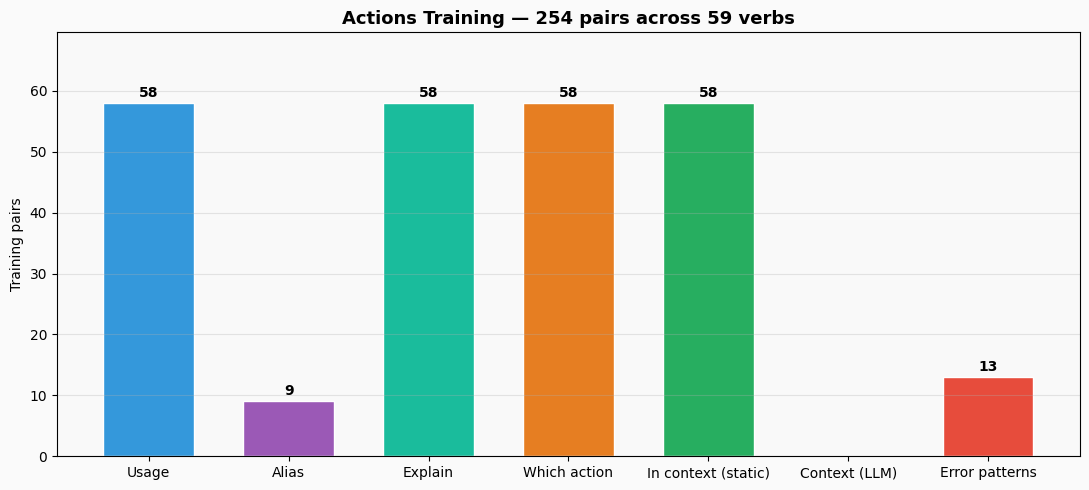

Saved: run/2026-03-26/05_actions_training.png


In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
from collections import Counter
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '05_actions_training.png'

# Load full own-file to get per-verb breakdown
_type_order = ['actions_usage', 'actions_alias', 'actions_explain',
               'actions_which', 'actions_context_static', 'actions_context', 'error_pattern']
_type_labels = ['Usage', 'Alias', 'Explain', 'Which action', 'In context (static)', 'Context (LLM)', 'Error patterns']
_type_colors = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#27ae60', '#2980b9', '#e74c3c']

_verb_data = {}   # verb → {type: count}
if OWN_FILE.exists():
    with open(OWN_FILE) as _f:
        for _line in _f:
            if not _line.strip(): continue
            _p = json.loads(_line)
            _m = __import__('re').search(r'`(\w+)` action', _p.get('instruction', ''))
            _v = _m.group(1) if _m else 'other'
            _s = _p.get('source', 'other')
            _verb_data.setdefault(_v, Counter())[_s] += 1

# Summary bar chart: total counts per type across all verbs
_totals_by_type = Counter()
for _vc in _verb_data.values():
    _totals_by_type.update(_vc)
# Also count error_pattern from PAIRS_FILE (written directly there)
_totals_by_type['error_pattern'] = len(ERROR_PATTERNS)

_heights = [_totals_by_type.get(t, 0) for t in _type_order]
_grand   = sum(_heights)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(_type_labels, _heights, color=_type_colors, edgecolor='white', width=0.65)
for bar, h in zip(bars, _heights):
    if h:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                str(h), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Training pairs')
ax.set_title(f'Actions Training — {_grand:,} pairs across {len(_verb_data)} verbs',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(_heights, default=1) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')

In [12]:
# ── Samples per category ─────────────────────────────────────────────────────
import json, random
from collections import defaultdict

_pairs = []
if OWN_FILE.exists():
    with open(OWN_FILE) as f:
        for line in f:
            if line.strip():
                _pairs.append(json.loads(line))

_by_src = defaultdict(list)
for p in _pairs:
    _by_src[p.get('source', 'unknown')].append(p)

_CATEGORY_ORDER = [
    'actions_usage',
    'actions_alias',
    'actions_explain',
    'actions_which',
    'actions_context_static',
    'actions_context',
    'error_pattern',
]
SAMPLES_PER_CAT = 2

for src in _CATEGORY_ORDER:
    pool = _by_src.get(src, [])
    if not pool:
        continue
    print(f'\n{"─"*72}')
    print(f'  {src}  ({len(pool)} pairs)')
    print('─'*72)
    for s in random.sample(pool, min(SAMPLES_PER_CAT, len(pool))):
        print(f'Q: {s["instruction"][:220]}')
        out = s.get('output', '')
        print(f'A: {out[:320]}{"..." if len(out) > 320 else ""}')
        print()


────────────────────────────────────────────────────────────────────────
  actions_usage  (58 pairs)
────────────────────────────────────────────────────────────────────────
Q: Show me how to use the `list` action in ARO.
A: List the <entries> from the <uploads-directory>.

Q: Show me how to use the `validate` action in ARO.
A: Validate the <valid> for the <email-address>.


────────────────────────────────────────────────────────────────────────
  actions_alias  (9 pairs)
────────────────────────────────────────────────────────────────────────
Q: How do I use `invoke` in ARO? (alias for call)
A: Invoke the <result> from the <payment-service>.

Q: How do I use `calculate` in ARO? (alias for compute)
A: Calculate the <total> from <price> * <quantity>.


────────────────────────────────────────────────────────────────────────
  actions_explain  (58 pairs)
────────────────────────────────────────────────────────────────────────
Q: What does this ARO statement do?

Start the <http-server>